In [1]:
# ====================
# CAPSTONE PROJECT EDA
# ====================

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

# Add project root to path to use methods from src.utils
sys.path.append(os.path.abspath(".."))
from src.utils import *

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report)

# Feature importance & explainability
# import shap

# Settings
# pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

print("Environment ready! ✓")

Environment ready! ✓


In [ ]:
# =======================
# STEP 1: PROBLEM FRAMING
# =======================

# Document your problem statement here
PROBLEM_STATEMENT = """
BUSINESS PROBLEM:
[Air pollution is a growing global challenge with severe consequences for public health and economic sustainability. 
According to the World Health Organization (WHO), air pollution is responsible for millions of premature deaths each year 
and is a major risk factor for lung diseases such as asthma, chronic obstructive pulmonary disease (COPD), lung cancer and 
respiratory infections. The WHO recommends strict limits on pollutants like fine particulate matter, nitrogen dioxide (NO₂) 
and ozone, emphasizing that reducing air pollution is one of the most effective ways to prevent non-communicable diseases 
and lower healthcare burdens.

Analyzing and understanding daily air quality data can play a crucial role in addressing these challenges. To do so, it is 
essential to identify which factors — such as temperature, humidity, time of day, and seasonal patterns — influence air quality 
levels.
By gaining these insights, actionable recommendations can be provided to the public to reduce exposure to harmful pollutants. 
For example, guidance can be given on when to avoid leaving the house or which times of day are safest for outdoor physical 
activities such as exercise.
In addition, weather forecasts combined with air quality predictions can be used proactively by authorities to manage traffic 
and industrial activity before pollution levels rise too high and exceed WHO-recommended thresholds. This preventive approach 
can help protect public health while reducing long-term healthcare costs.]

ML TASK TYPES:
[Classification / Regression / Clustering / Anomaly Detection / Recommendation]

SUCCESS METRICS:
- Technical: [Accuracy > 0.75, F1 > 0.75]
- Business: [Provide recommendations to the public on whether it is safe to leave the house:
	YES (Green)     -> Safe to go outside
	AVOID (Yellow)  -> Limit outdoor activities
	DANGER (Red)    -> Stay indoors, WHO-recommended threshold was exceeded

TARGET VARIABLE:
[Air pollution levels exceeded the WHO-recommended threshold for this toxin]
"""

print(PROBLEM_STATEMENT)

In [ ]:
# ==========================================
# STEP 2: DATA LOADING & INITIAL EXPLORATION
# ==========================================

# Load your dataset
df: pd.DataFrame = pd.read_csv('../data/AirQualityUCI.csv', delimiter=';')

# Thresholds for each toxin by 'WHO Air Quality Guidlines (AQG)' or 'European Environment Agency (EEA)' - 'None' if no threshold is defined yet
# Source of comment behind each toxin: https://archive.ics.uci.edu/dataset/360/air+quality
thresholds: dict = {
    'CO(GT)': 4,            # True hourly averaged concentration CO in mg/m^3                                   - WHO AQG page: 134
    'NMHC(GT)': None,       # True hourly averaged overall Non Metanic HydroCarbons concentration in microg/m^3 - No threshold defined yet
    'C6H6(GT)': 5,          # True hourly averaged Benzene concentration in microg/m^3                          - EEA homepage
    'NOx(GT)': None,        # True hourly averaged NOx concentration in ppb                                     - No threshold defined yet
    'NO2(GT)': 10,          # True hourly averaged NO2 concentration in microg/m^3                              - WHO AQG page: 116
    'PT08.S5(O3) ': 60      # Hourly averaged sensor response (nominally O3 targeted)                           - WHO AQG page: 136
}

# Feature labels
labels: dict = {
    'Date': 'Date (dd/mm/yyyy)',
    'Time': 'Time (hh.mm.ss)',
    'CO(GT)': 'CO concencration in mg/m^3',
    'PT08.S1(CO)': 'Hourly averaged sensor response (nominally CO targeted)',
    'NMHC(GT)': 'Non Metanic HydroCarbons concentration in microg/m^3',
    'C6H6(GT)': 'Benzene concentration in microg/m^3',
    'PT08.S2(NMHC)': 'Hourly averaged sensor response (nominally NMHC targeted)',
    'NOx(GT)': 'NOx concentration in ppb ',
    'PT08.S3(NOx)': 'Hourly averaged sensor response (nominally NOx targeted)',
    'NO2(GT)': 'NO2 concentration in microg/m^3 ',
    'PT08.S4(NO2)': 'Hourly averaged sensor response (nominally NO2 targeted)',
    'PT08.S5(O3)': 'Ozon (O3)',
    'T': 'Temperature (°C)',
    'RH': 'Relative Humidity (%)',
    'AH': 'Absolute Humidity'
}

# Feature labels for graphs (shorter vesions)
labels_short: dict = {
    'Date': 'Date',
    'Time': 'Time',
    'CO(GT)': 'CO',
    'PT08.S1(CO)': 'CO',
    'NMHC(GT)': 'Non Metanic HydroCarbons',
    'C6H6(GT)': 'Benzene',
    'PT08.S2(NMHC)':'Non Metanic HydroCarbons',
    'NOx(GT)': 'NOx',
    'PT08.S3(NOx)': 'NOx',
    'NO2(GT)': 'NO2',
    'PT08.S4(NO2)': 'NO2',
    'PT08.S5(O3)': 'Ozon',
    'T': '°C',
    'RH': 'Humidity (%)',
    'AH': 'Abs. Humidity'
}

# Quick overview
def data_overview(df):
    """Print comprehensive data overview."""
    print("="*60)
    print("DATASET OVERVIEW")
    print("="*60)
    print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"\nColumn Types:\n{df.dtypes.value_counts()}")
    print(f"\nMissing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"\nFirst 5 Rows:")
    display(df.head())

# Print results:
# data_overview(df) # Shape: 9471 rows × 17 columns (two unnamed colums with no data)

# Drop columns using regex in filter
df = df.drop(df.filter(regex="Unnamed").columns, axis=1)

# Check rows with no data
rows_to_drop: list = []
is_nan: tuple[np.ndarray, np.ndarray] = np.where(pd.isnull(df)) # tuple[np.ndarray -> indices of column, np.ndarray -> indices of rows]
for i_row, i_col in zip(is_nan[0], is_nan[1]):
    # print(f'Row: {i_row}, Column: {i_col}, Value: {df.iloc[i_row, i_col]}')
    if i_row not in rows_to_drop:
        rows_to_drop.append(i_row) # rows with no data in csv-file

# Drop rows with NaN
df = df.drop(index=rows_to_drop)
# data_overview(df) # Shape: 9357 rows × 15 columns => NO missing values!






# TODO
# Check for negative values and drop rows
#numeric_cols = df.select_dtypes(include=['number'])
#neg_indices = df.index[(numeric_cols < 0).any(axis=1)]
#df_filtered = df.drop(index=neg_indices)
#data_overview(df_filtered)

# Save cleaned data to file (pickle)
#df.to_pickle('../data/AirQualityUCICleaned.pkl')

DATASET OVERVIEW

Shape: 9357 rows × 15 columns

Memory Usage: 3.97 MB

Column Types:
float64    8
object     7
Name: count, dtype: int64

Missing Values:
Series([], dtype: int64)

First 5 Rows:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


# Column name: CO(GT)
Types found (CO(GT)): object
Types found (CO(GT)_to_float): float64
Neg. values (CO(GT)_to_float): 1683


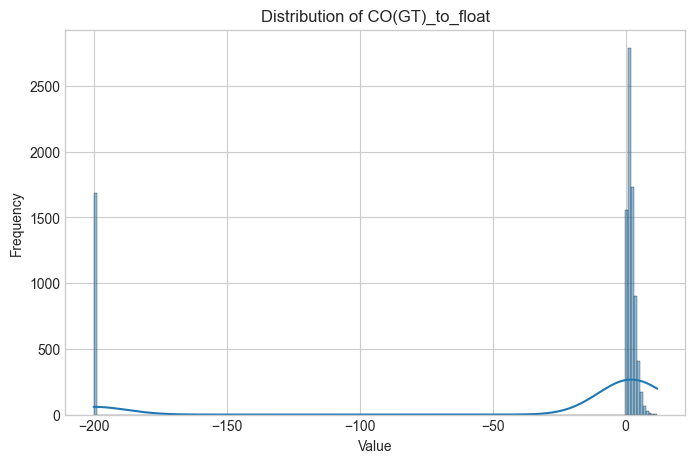

In [ ]:
# Analyze each column 
analyze_col(df, 'CO(GT)', True)
''' 
    1. Found 1,683 negative values when dtype 'object' was converted to 'float'
    2. All negatives have the same value of -200 (maybe this is an error code)
'''
# TODO: Replace each '-200' with the average value of the row before and after it, e.g.: 0.4 -200 0.6 -> 0.4 0.5 0.6


In [ ]:
# =============================================================================
# STEP 3: EDA & FEATURE ENGINEERING (Template)
# =============================================================================

# 3a. Missing Value Analysis
def analyze_missing(df):
    """Analyze missing values in dataset."""
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    })
    return missing_df[missing_df['Missing Count'] > 0].sort_values(
        'Missing %', ascending=False
    )

# 3b. Distribution plotting
def plot_distributions(df, columns, figsize=(15, 5)):
    """Plot distributions of specified columns."""
    n_cols = min(3, len(columns))
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

    for idx, col in enumerate(columns):
        if df[col].dtype in ['int64', 'float64']:
            axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black')
        else:
            df[col].value_counts().plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(col)

    plt.tight_layout()
    plt.show()

print("EDA functions defined ✓")